In [5]:
import pandas as pd
df = pd.read_csv(r"C:\Users\ertur\OneDrive\Desktop\Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [22]:
#Hedef değişken(target) oluşturdum 1:geç teslimat 0:zamanında

In [22]:
df['Is_Late'] = (df['Delivery_Time_min'] > 30).astype(int)

In [ ]:
# Sayısal olan tecrübe yılını ortalama ile doldurdum
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

In [8]:
# Kategorik olanları en sık tekrar eden değerle doldurdum
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

In [9]:
#sıralı değişkeni numeric yaptım
df['Traffic_Level'] = df['Traffic_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

In [10]:
#araç tipi hava durumu gün zamanı sayıya çevirdim
df = pd.get_dummies(df, columns=['Vehicle_Type', 'Weather', 'Time_of_Day'], drop_first=True)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Tahminde kullanılacak sayısal sütunları seçtim
sayisal_sutunlar = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
df[sayisal_sutunlar] = scaler.fit_transform(df[sayisal_sutunlar])

In [12]:
#x ve y yi ayırdım
X = df.drop(['Order_ID', 'Delivery_Time_min', 'Is_Late'], axis=1) # Girdiler
y = df['Is_Late'] # Hedef

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
#beta katsayısını hesapladım
Beta katsayıları değişkenlerin gecikme olasılığı üzerindeki yönünü ve gücünü gösterir
beta_values = pd.DataFrame({
    "Feature": X.columns,
    "Beta_Coefficient": model.coef_[0]
})
print(beta_values)

                   Feature  Beta_Coefficient
0              Distance_km          4.563910
1            Traffic_Level          1.524168
2     Preparation_Time_min          2.314295
3   Courier_Experience_yrs         -0.393530
4         Vehicle_Type_Car         -0.380183
5     Vehicle_Type_Scooter         -0.320667
6            Weather_Foggy          1.049888
7            Weather_Rainy          1.362882
8            Weather_Snowy          2.155854
9            Weather_Windy         -0.059754
10     Time_of_Day_Evening          0.177669
11     Time_of_Day_Morning         -0.035502
12       Time_of_Day_Night         -0.508205


In [16]:
import numpy as np

beta_values["Odds_Ratio"] = np.exp(beta_values["Beta_Coefficient"])
print(beta_values)

                   Feature  Beta_Coefficient  Odds_Ratio
0              Distance_km          4.563910   95.957976
1            Traffic_Level          1.524168    4.591321
2     Preparation_Time_min          2.314295   10.117789
3   Courier_Experience_yrs         -0.393530    0.674671
4         Vehicle_Type_Car         -0.380183    0.683736
5     Vehicle_Type_Scooter         -0.320667    0.725665
6            Weather_Foggy          1.049888    2.857330
7            Weather_Rainy          1.362882    3.907438
8            Weather_Snowy          2.155854    8.635266
9            Weather_Windy         -0.059754    0.941996
10     Time_of_Day_Evening          0.177669    1.194430
11     Time_of_Day_Morning         -0.035502    0.965121
12       Time_of_Day_Night         -0.508205    0.601574


In [17]:
#modelin çalışıp çalışmadığını öğrendim
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.955
[[ 18   5]
 [  4 173]]
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        23
           1       0.97      0.98      0.97       177

    accuracy                           0.95       200
   macro avg       0.90      0.88      0.89       200
weighted avg       0.95      0.95      0.95       200



In [18]:
from sklearn.metrics import log_loss

ll_model = -log_loss(y_test, model.predict_proba(X_test))
ll_null = -log_loss(y_test, [y_test.mean()] * len(y_test))

pseudo_r2 = 1 - (ll_model / ll_null)

print("Pseudo R2:", pseudo_r2)

Pseudo R2: 0.7215935142620009


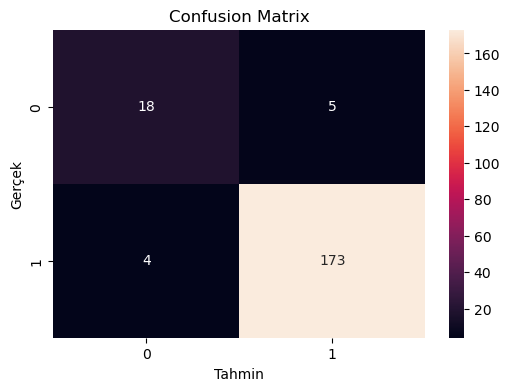

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

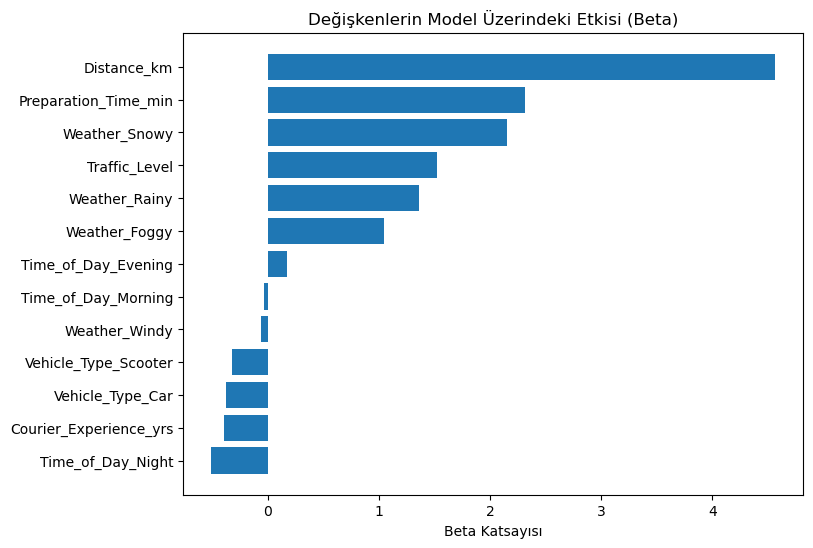

In [20]:
#beta etkileri
beta_values.sort_values("Beta_Coefficient", inplace=True)
plt.figure(figsize=(8,6))
plt.barh(beta_values["Feature"], beta_values["Beta_Coefficient"])
plt.title("Değişkenlerin Model Üzerindeki Etkisi (Beta)")
plt.xlabel("Beta Katsayısı")
plt.show()

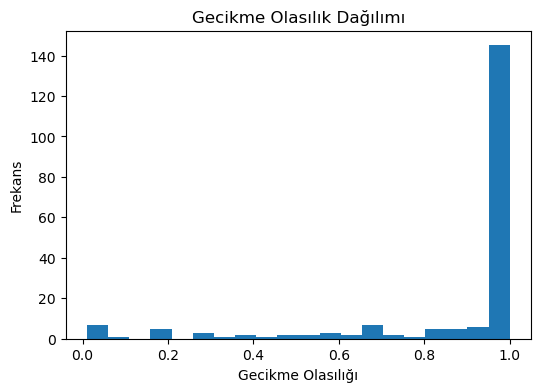

In [21]:
y_prob = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
plt.hist(y_prob, bins=20)
plt.title("Gecikme Olasılık Dağılımı")
plt.xlabel("Gecikme Olasılığı")
plt.ylabel("Frekans")
plt.show()

In [23]:
#modelin gecikme eğilimi
print(model.intercept_)

[5.15260659]


In [ ]:
Lojistik regresyon modeli BAŞARILI çalıştı
accuracy:0.955 yani model ½95.5 i doğru tahmin etti
Geç teslimatlar için Recall = 0.98
beta 4.56 Mesafe arttıkça gecikme çok artıyor
2.31 Hazırlık süresi geciktiriyor
1.52 Trafik gecikme sebebi
2.15 Karlı hava ciddi etki

Pseudo R2: 0.72 modelim güçlü gecikmenin büyük kısmını açıklıyor

Model her teslimat için gecikme olasılığı hesaplamakta 
ve belirli bir eşik değerine göre sınıflandırma yapmaktadır